<a href="https://colab.research.google.com/github/RobsonLost/ads---faculdade/blob/main/Sistema_de_gerenciamento_de_biblioteca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos os livros
3 - Buscar livro por título
4 - Gerar gráfico por gênero
0 - Sair

=== CADASTRO DE NOVO LIVRO ===
✅ Livro 'Dom Casmurro' cadastrado com sucesso!

   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos os livros
3 - Buscar livro por título
4 - Gerar gráfico por gênero
0 - Sair

=== CADASTRO DE NOVO LIVRO ===
✅ Livro 'O Hobbit' cadastrado com sucesso!

   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos os livros
3 - Buscar livro por título
4 - Gerar gráfico por gênero
0 - Sair

=== CADASTRO DE NOVO LIVRO ===
✅ Livro '1984' cadastrado com sucesso!

   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos os livros
3 - Buscar livro por título
4 - Gerar gráfico por gênero
0 - Sair
⚠️  Opção inválida! Digite um número de 0 a 4.

   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos

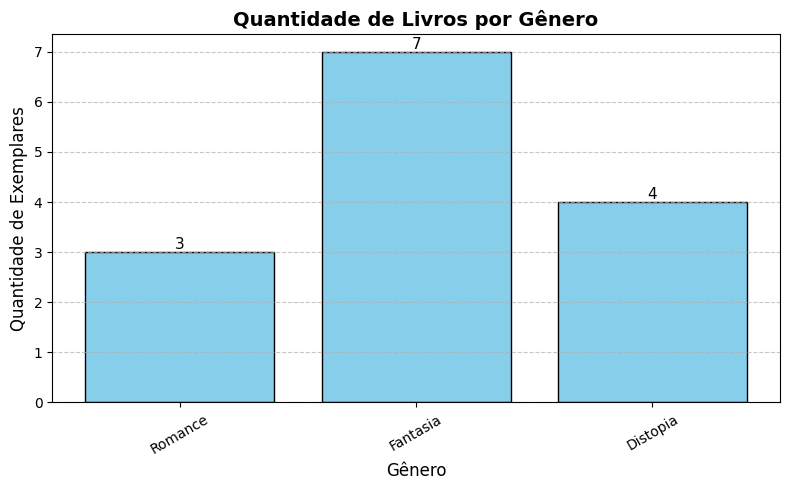


   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL
1 - Cadastrar novo livro
2 - Listar todos os livros
3 - Buscar livro por título
4 - Gerar gráfico por gênero
0 - Sair


KeyboardInterrupt: Interrupted by user

In [1]:
# ------------------------------------------------------------
# PASSO 1: Definição da classe Livro
# ------------------------------------------------------------
class Livro:
    """
    Representa um livro dentro do sistema da biblioteca.
    Cada livro possui: título, autor, gênero e quantidade disponível.
    """

    # Método construtor: executado automaticamente ao criar um novo objeto Livro.
    def __init__(self, titulo, autor, genero, quantidade):
        self.titulo = titulo            # Título do livro
        self.autor = autor              # Autor do livro
        self.genero = genero            # Gênero literário (ex: Romance, Fantasia)
        self.quantidade = quantidade    # Quantidade disponível no acervo

    # Método especial __str__: define como o livro será exibido ao usar print().
    def __str__(self):
        return (f"📖 Título: {self.titulo} | Autor: {self.autor} | "
                f"Gênero: {self.genero} | Quantidade: {self.quantidade}")


# ------------------------------------------------------------
# PASSO 2: Criação da lista que armazenará os livros
# ------------------------------------------------------------
# Lista global que vai guardar todos os objetos Livro cadastrados.
biblioteca = []


# ------------------------------------------------------------
# PASSO 3: Funções para gerenciar os livros
# ------------------------------------------------------------

def cadastrar_livro():
    """
    Solicita ao usuário os dados de um novo livro e adiciona à lista 'biblioteca'.
    Valida a quantidade para garantir que seja um número inteiro positivo.
    """
    print("\n=== CADASTRO DE NOVO LIVRO ===")
    titulo = input("Título do livro: ").strip()
    autor = input("Autor do livro: ").strip()
    genero = input("Gênero do livro: ").strip()

    # Laço de repetição para validar a quantidade (deve ser número inteiro >= 0).
    while True:
        try:
            quantidade = int(input("Quantidade disponível: "))
            if quantidade < 0:
                print("⚠️  A quantidade não pode ser negativa. Tente novamente.")
            else:
                break  # Sai do laço quando a quantidade é válida
        except ValueError:
            # Caso o usuário digite algo que não seja número inteiro.
            print("⚠️  Entrada inválida! Digite um número inteiro.")

    # Cria o objeto Livro e o adiciona à lista da biblioteca.
    novo_livro = Livro(titulo, autor, genero, quantidade)
    biblioteca.append(novo_livro)
    print(f"✅ Livro '{titulo}' cadastrado com sucesso!")


def listar_livros():
    """
    Percorre a lista 'biblioteca' e exibe todos os livros cadastrados.
    Caso a lista esteja vazia, informa ao usuário.
    """
    print("\n=== LISTA DE LIVROS CADASTRADOS ===")
    if not biblioteca:
        print("📭 Nenhum livro cadastrado até o momento.")
        return

    # enumerate() fornece o índice e o objeto ao mesmo tempo, facilitando a numeração.
    for i, livro in enumerate(biblioteca, start=1):
        print(f"{i}. {livro}")


def buscar_livro_por_titulo():
    """
    Solicita um título ao usuário e procura na lista 'biblioteca'.
    A busca é feita ignorando maiúsculas/minúsculas para ser mais amigável.
    """
    print("\n=== BUSCAR LIVRO PELO TÍTULO ===")
    if not biblioteca:
        print("📭 Nenhum livro cadastrado para buscar.")
        return

    termo = input("Digite o título (ou parte dele): ").strip().lower()
    encontrados = [livro for livro in biblioteca if termo in livro.titulo.lower()]

    if encontrados:
        print(f"\n🔎 {len(encontrados)} livro(s) encontrado(s):")
        for livro in encontrados:
            print(f"   {livro}")
    else:
        print(f"❌ Nenhum livro encontrado com o termo '{termo}'.")


# ------------------------------------------------------------
# PASSO 4: Geração do gráfico com Matplotlib
# ------------------------------------------------------------

def gerar_grafico_por_genero():
    """
    Conta quantos livros existem em cada gênero e gera um gráfico de barras
    utilizando a biblioteca Matplotlib.
    """
    print("\n=== GRÁFICO DE LIVROS POR GÊNERO ===")

    if not biblioteca:
        print("📭 Nenhum livro cadastrado para gerar o gráfico.")
        return

    # Dicionário para armazenar a contagem: {gênero: quantidade_de_livros}
    contagem_generos = {}

    # Percorre cada livro e incrementa a contagem do seu gênero.
    for livro in biblioteca:
        # Soma a quantidade de exemplares disponíveis por gênero.
        contagem_generos[livro.genero] = contagem_generos.get(livro.genero, 0) + livro.quantidade

    # Separa as chaves (gêneros) e os valores (quantidades) em listas.
    generos = list(contagem_generos.keys())
    quantidades = list(contagem_generos.values())

    # Criação do gráfico de barras
    plt.figure(figsize=(8, 5))                       # Define o tamanho da figura
    barras = plt.bar(generos, quantidades, color='skyblue', edgecolor='black')

    # Adiciona rótulos com os valores acima de cada barra
    for barra in barras:
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width() / 2, altura,
                 f'{int(altura)}', ha='center', va='bottom', fontsize=11)

    # Títulos e rótulos dos eixos
    plt.title("Quantidade de Livros por Gênero", fontsize=14, fontweight='bold')
    plt.xlabel("Gênero", fontsize=12)
    plt.ylabel("Quantidade de Exemplares", fontsize=12)
    plt.xticks(rotation=30)                          # Rotaciona os nomes dos gêneros
    plt.grid(axis='y', linestyle='--', alpha=0.7)    # Linhas de grade horizontais
    plt.tight_layout()                               # Ajusta o layout para não cortar textos
    plt.show()                                       # Exibe o gráfico na tela


# ------------------------------------------------------------
# PASSO 5: Função principal (menu do sistema)
# ------------------------------------------------------------

def menu():
    """
    Exibe o menu principal e direciona o usuário para a funcionalidade escolhida.
    O laço 'while' mantém o programa em execução até o usuário escolher sair.
    """
    while True:
        print("\n" + "=" * 45)
        print("   SISTEMA DE BIBLIOTECA - MENU PRINCIPAL")
        print("=" * 45)
        print("1 - Cadastrar novo livro")
        print("2 - Listar todos os livros")
        print("3 - Buscar livro por título")
        print("4 - Gerar gráfico por gênero")
        print("0 - Sair")
        print("=" * 45)

        opcao = input("Escolha uma opção: ").strip()

        if opcao == "1":
            cadastrar_livro()
        elif opcao == "2":
            listar_livros()
        elif opcao == "3":
            buscar_livro_por_titulo()
        elif opcao == "4":
            gerar_grafico_por_genero()
        elif opcao == "0":
            print("\n👋 Encerrando o sistema. Até logo!")
            break
        else:
            print("⚠️  Opção inválida! Digite um número de 0 a 4.")


# Ponto de entrada do programa: só executa o menu se este arquivo for o principal.
if __name__ == "__main__":
    menu()